In [1]:
import numpy as np

def _sigmoid(x): return 1.0 / (1.0 + np.exp(-x))
def _logit(p, eps=1e-6): 
    p = np.clip(p, eps, 1.0 - eps) 
    return np.log(p / (1.0 - p))

def make_bounded_regression(n_samples=512,
                            n_features=128,
                            rho=0.5,          # feature correlation (AR(1)-style)
                            n_informative=5,  # how many features truly matter
                            noise_std=0.5,    # latent Gaussian noise (on g)
                            beta_k=50.0,      # Beta concentration for y-noise (larger = less noise)
                            seed=42):
    """
    Returns:
      X: (n_samples, n_features)
      y: (n_samples,) in [0,1]
      info: dict with latent f, weights, and diagnostics
    """
    rng = np.random.default_rng(seed)

    # --- Correlated Gaussian features X ~ N(0, Sigma) with Toeplitz structure ---
    # Sigma_ij = rho^|i-j|
    idx = np.arange(n_features)
    Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma)
    X = rng.standard_normal((n_samples, n_features)) @ L.T

    # --- Sparse informative weights for linear part ---
    w = np.zeros(n_features)
    informative_idx = rng.choice(n_features, size=n_informative, replace=False)
    w[informative_idx] = rng.normal(0, 1.0, size=n_informative)

    # --- Latent signal: linear + mild nonlinear interactions ---
    f = X @ w
    if n_features >= 5:
        f += 0.5*np.sin(X[:, 0]) + 0.3*X[:, 1]*X[:, 2] + 0.5*np.tanh(X[:, 3] - 0.5*X[:, 4])

    # --- Add Gaussian noise in latent (unbounded) space ---
    g = f + rng.normal(0, noise_std, size=n_samples)

    # --- Map to [0,1] via sigmoid ---
    p = 1.0 / (1.0 + np.exp(-g))
    p = np.clip(p, 1e-6, 1 - 1e-6)

    # --- Optional: add Beta noise on probability scale for continuous y in [0,1] ---
    # Var(y | p) = p(1-p)/(beta_k+1); set beta_k large for tight noise around p
    alpha = beta_k * p
    beta = beta_k * (1 - p)
    y = rng.beta(alpha, beta)

    # Diagnostics
    corr_f_y = float(np.corrcoef(f, y)[0, 1])
    info = {
        "Sigma": Sigma,
        "weights": w,
        "informative_idx": informative_idx,
        "latent_f": f,
        "latent_g": g,
        "p": p,
        "corr_f_y": corr_f_y,
    }
    return X, y, info

In [2]:
# Create a toy dataset X, y

np.random.seed(42)
X, y, info = make_bounded_regression(
        n_samples=512, n_features=128,
        rho=0.6,          # stronger feature correlation
        n_informative=6,
        noise_std=0.4,    # lower => stronger correlation
        beta_k=80.0,      # higher => y is closer to p (less noise)
        seed=42
    )

print('X shape:', X.shape)
print('y shape:', y.shape)
print('y min:', y.min(), 'y max:', y.max())

X shape: (512, 128)
y shape: (512,)
y min: 0.007018269530620342 y max: 0.999996352130582


In [8]:
# Fit and evaluate a Gaussian Process regression model
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define kernel and model
kernel = (
    C(1.0, (1e-3, 1e3)) *
    RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3))
    + WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-6, 1e1))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,
    n_restarts_optimizer=1,   # increase to 5–10 if you can afford more time
    random_state=42
)
# Fit model
gpr.fit(X_train, y_train)

# Predict
y_pred, y_std = gpr.predict(X_test, return_std=True)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse:.4f}')
print(f'R^2 Score: {r2:.4f}')

Mean Squared Error: 0.0190
R^2 Score: 0.7438


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- transform targets to logit space ---
y_train_logit = _logit(y_train)
y_test_logit  = _logit(y_test)   # for diagnostics only

# --- kernel & model ---
kernel = (
    C(1.0, (1e-3, 1e3))
    * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e3))
    + WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-6, 1e1))
)

gpr = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=False,         # we already centered via logit (unbounded)
    n_restarts_optimizer=5,    # bump this if you can afford it
    alpha=1e-10,               # tiny nugget for stability
    random_state=42,
)

# --- fit on logit targets ---
gpr.fit(X_train, y_train_logit)

# --- predict in logit space, then map back with sigmoid ---
y_mean_logit, y_std_logit = gpr.predict(X_test, return_std=True)
y_pred = _sigmoid(y_mean_logit)

# --- metrics in original [0,1] space ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error (prob space): {mse:.4f}")
print(f"R^2 Score (prob space):         {r2:.4f}")

# --- (optional) diagnostics in logit space ---
logit_mse = mean_squared_error(y_test_logit, y_mean_logit)
print(f"MSE (logit space):               {logit_mse:.4f}")

# --- (optional) approximate predictive std in prob space via delta method ---
# var_p ≈ (σ(m)*(1-σ(m)))^2 * var_logit  => std_p ≈ σ(m)*(1-σ(m)) * std_logit
p = y_pred
y_std_prob_approx = p * (1.0 - p) * y_std_logit

Mean Squared Error (prob space): 0.0766
R^2 Score (prob space):         -0.0324
MSE (logit space):               4.5486


True: 0.935, Predicted: 0.748, Std: 0.151
True: 0.710, Predicted: 0.656, Std: 0.138
True: 0.663, Predicted: 0.598, Std: 0.139
True: 0.804, Predicted: 0.622, Std: 0.154
True: 0.735, Predicted: 0.628, Std: 0.146


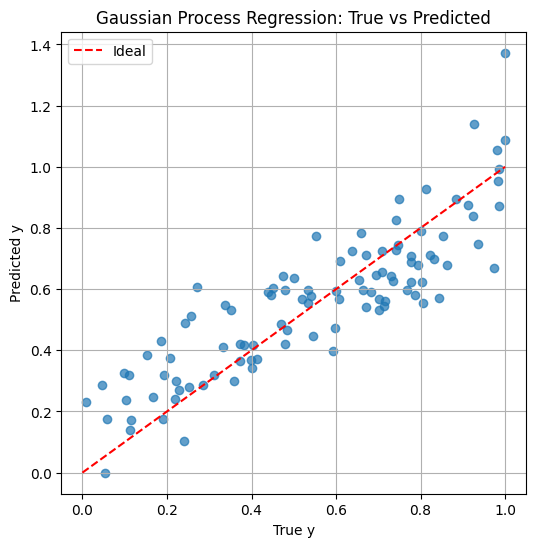

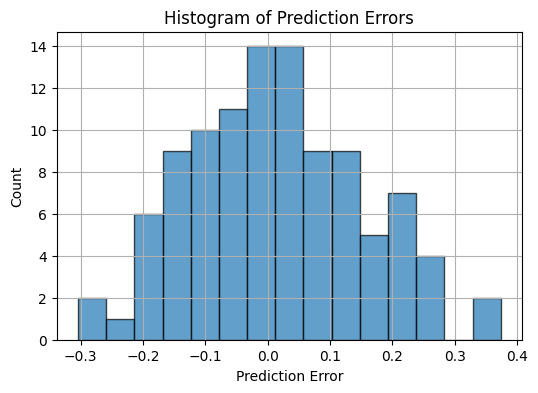

In [9]:
# Visualize predictions and analyze results
import matplotlib.pyplot as plt

# Print a few prediction examples
for i in range(5):
    print(f"True: {y_test[i]:.3f}, Predicted: {y_pred[i]:.3f}, Std: {y_std[i]:.3f}")

# Scatter plot of true vs predicted values
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([0,1],[0,1],'r--',label='Ideal')
plt.xlabel('True y')
plt.ylabel('Predicted y')
plt.title('Gaussian Process Regression: True vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

# Histogram of prediction errors
errors = y_pred - y_test
plt.figure(figsize=(6,4))
plt.hist(errors, bins=15, edgecolor='k', alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.title('Histogram of Prediction Errors')
plt.grid(True)
plt.show()

In [6]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# ---------- helpers ----------
def sigmoid(x): return 1 / (1 + np.exp(-x))
def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

# If X, y not already defined, make a correlated bounded dataset:
try:
    X, y
except NameError:
    rng = np.random.default_rng(42)
    n_samples, n_features = 512, 16
    rho = 0.6
    idx = np.arange(n_features)
    Sigma = rho ** np.abs(idx[:, None] - idx[None, :])
    L = np.linalg.cholesky(Sigma)
    X = rng.standard_normal((n_samples, n_features)) @ L.T

    w = np.zeros(n_features)
    w[rng.choice(n_features, 6, replace=False)] = rng.normal(0, 1, 6)
    f = X @ w + 0.5*np.sin(X[:,0]) + 0.3*X[:,1]*X[:,2]
    g = f + rng.normal(0, 0.4, n_samples)
    p = sigmoid(g)
    # add mild Beta noise to keep y in [0,1]
    k = 80.0
    y = rng.beta(k*p, k*(1-p))

# ---------- split ----------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- baselines ----------

# 1) Mean-only baseline
y_pred_mean = np.full_like(y_test, fill_value=y_train.mean())
mse_mean = mean_squared_error(y_test, y_pred_mean)

# 2) Linear regression on y with clipping to [0,1]
lin = make_pipeline(StandardScaler(), LinearRegression())
lin.fit(X_train, y_train)
y_pred_lin = np.clip(lin.predict(X_test), 0.0, 1.0)
mse_lin = mean_squared_error(y_test, y_pred_lin)

# 3) Logit-linear baseline (Ridge on logit(y), inverse-logit back)
ridge_logit = make_pipeline(StandardScaler(), Ridge(alpha=1.0, random_state=42))
ridge_logit.fit(X_train, logit(y_train))
y_pred_logit = sigmoid(ridge_logit.predict(X_test))
mse_logit = mean_squared_error(y_test, y_pred_logit)

print("MSE – Mean baseline        :", f"{mse_mean:.6f}")
print("MSE – Linear + clip [0,1]  :", f"{mse_lin:.6f}")
print("MSE – Logit-Ridge (plugin) :", f"{mse_logit:.6f}")

MSE – Mean baseline        : 0.074183
MSE – Linear + clip [0,1]  : 0.016811
MSE – Logit-Ridge (plugin) : 0.014142
